# Paleo SST anomaly patterns

Equal-weight mean LGM reconstruction, plioDA **KM5c / PlioVar**, and the prescribed **LongRunMIP 2×CO₂** pattern. Anomalies are relative to each suite's LGMR late-Holocene baseline (called `Preindustrial` in the source notebooks).

Sources in `/glade/u/home/vcooper/projects/plio_pattern/analysis` (cell indices below are zero-based):

- `hydro_analysis.ipynb`, cell 24 (`lgm['CAM4']`), and `hydro_monthly.ipynb`: the four LGM patterns **LGMR, Annan, Amrhein, Tierney**. The loading definitions and individual maps were located; a pre-existing four-pattern averaging cell was not located. Here the four **dimensional anomalies are averaged first**, then normalized.
- `plio_analysis.ipynb`, cell 24: `plioDA['CAM5']['PlioVar']`, `LongRunMIP`, and their matching baseline. Cell 46 explicitly identifies PlioVar as “KM5c Only” and uses the custom `BuOr` map. We use the CAM5 prescribed SST for both warm patterns, not the atmospheric temperature response.
- `single_forcing_clean.ipynb`: full-LGM iCESM1.2 case `b.e12.B1850C5.f19_g16.i21ka.03`, climatology years 801–900, for `LANDFRAC`.
- `hydro_analysis.ipynb`, cell 6: `domain.lnd.fv0.9_1.25_gx1v6plioenh.190801_latlon.nc` for Pliocene land fraction.
- `bayecs/cmip6_hist_ens.ipynb` and `figures/ecs/fig_sst_pattern.png`: Pacific-centered Robinson projection, serif typography, gray land, thin black coastlines, dashed graticules, and a shared discrete colorbar.

Normalization follows `plio_analysis` exactly: local ΔSST divided by **|global open-ocean mean ΔSST|**, with cell-area weights at modern land fraction < 0.0001. Thus cooling remains negative. This is a global normalization, unlike the 60°S–60°N normalization in the historical comparison notebook. The coastline masks affect display, not this common normalization domain.

Paleo shorelines are the **0.5 land-fraction contour at the model grid resolution**. The prescribed SST fields include infilled values over modern land; changing the displayed coastlines does not reconstruct additional SST information in newly exposed ocean areas. No modern coastlines or modern land polygons are drawn on the paleo panels.

Executed and checked using the `aris` conda environment. The notebook retains the source-path table, normalization diagnostics, and rendered figure.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from IPython.display import display

DATA_ROOT = Path('/glade/u/home/vcooper/projects/plio_pattern/data')
ARCHIVE_ROOT = Path('/glade/derecho/scratch/vcooper/archive')
BAYECS_ROOT = Path('/glade/u/home/vcooper/work/hist_sst/bayecs')
FIGURE_DIR = BAYECS_ROOT / 'figures' / 'ecs'
SAVE_FIGURES = True
VABS = 2.5
NLEVELS = 20
COAST_THRESHOLD = 0.5

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['TeX Gyre Termes', 'Times New Roman', 'Times', 'STIXGeneral'],
    'mathtext.fontset': 'stix', 'font.size': 9,
    'axes.titlesize': 10, 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

## Load the prescribed SST climatologies

Use the same equal-month average over the final 25 simulation years as `loadtseries_case30yr` in the source notebooks. CAM monthly timestamps denote the following month's start; the source date slice selects 300 months, January year 6 through December year 30. Coordinate alignment is checked explicitly before subtracting or stacking fields.

In [2]:
LGM_CASES = {
    'LGMR': 'f.e1221.F_2000.f19_f19.LGMRlgm.003',
    'Annan': 'f.e1221.F_2000.f19_f19.annan-seasbyamr.002.1',
    'Amrhein': 'f.e1221.F_2000.f19_f19.amrhein.002.1',
    'Tierney': 'f.e1221.F_2000.f19_f19.lgmDA.002',
}
LGM_BASELINE = 'f.e1221.F_2000.f19_f19.LGMRholo.003'
PLIOVAR_CASE = 'f.e215.F2000climoCAM5.f19_f19.tplio_vFpliovar'
LONGRUNMIP_CASE = 'f.e215.F2000climoCAM5.f19_f19.longrunmip.002'
WARM_BASELINE = 'f.e215.F2000climoCAM5.f19_f19.LGMRholo.003'
source_records = []


def load_sst(case):
    path = (ARCHIVE_ROOT / case / 'atm/proc/tseries/month_1'
            / f'{case}.cam.h0.SST.000101-003012.nc')
    with xr.open_dataset(path) as ds:
        monthly = ds['SST'].sel(time=slice('0006-01-02', '0031-01-01'))
        assert monthly.sizes['time'] == 300, f'Unexpected month count: {case}'
        field = monthly.mean('time', skipna=False).load().transpose('lat', 'lon')
    field.attrs.update(source=str(path), case=case, units='K',
                       averaging='Equal-month mean, simulation years 6–30')
    source_records.append({'case': case, 'variable': 'SST', 'source': str(path)})
    return field


def anomaly(field, baseline):
    field, baseline = xr.align(field, baseline, join='exact')
    result = field - baseline
    result.attrs.update(units='K', source=field.attrs['source'],
                        baseline_source=baseline.attrs['source'])
    return result


lgm_baseline = load_sst(LGM_BASELINE)
warm_baseline = load_sst(WARM_BASELINE)
lgm_members = xr.concat(
    [anomaly(load_sst(case), lgm_baseline) for case in LGM_CASES.values()],
    dim=pd.Index(LGM_CASES, name='reconstruction'), join='exact',
).rename('lgm_sst_anomaly_members')
# Require all four values: no local change in ensemble membership.
lgm_mean = lgm_members.mean('reconstruction', skipna=False)
plio_anomaly = anomaly(load_sst(PLIOVAR_CASE), warm_baseline)
longrun_anomaly = anomaly(load_sst(LONGRUNMIP_CASE), warm_baseline)
sst_anomaly = xr.concat(
    [lgm_mean, plio_anomaly, longrun_anomaly],
    dim=pd.Index(['LGM', 'Pliocene', 'LongRunMIP'], name='pattern'), join='exact',
).rename('sst_anomaly')
sst_anomaly.attrs = {'units': 'K', 'long_name': 'Prescribed SST anomaly relative to late Holocene'}
assert lgm_members.sizes['reconstruction'] == 4
assert np.isfinite(sst_anomaly).all().item()
display(pd.DataFrame(source_records))

,case,variable,source
0,f.e1221.F_2000.f19_f19.LGMRholo.003,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
1,f.e215.F2000climoCAM5.f19_f19.LGMRholo.003,SST,/glade/derecho/scratch/vcooper/archive/f.e215....
2,f.e1221.F_2000.f19_f19.LGMRlgm.003,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
3,f.e1221.F_2000.f19_f19.annan-seasbyamr.002.1,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
4,f.e1221.F_2000.f19_f19.amrhein.002.1,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
5,f.e1221.F_2000.f19_f19.lgmDA.002,SST,/glade/derecho/scratch/vcooper/archive/f.e1221...
6,f.e215.F2000climoCAM5.f19_f19.tplio_vFpliovar,SST,/glade/derecho/scratch/vcooper/archive/f.e215....
7,f.e215.F2000climoCAM5.f19_f19.longrunmip.002,SST,/glade/derecho/scratch/vcooper/archive/f.e215....


## Land fractions and normalization

Keep the native Pliocene 0.9° × 1.25° grid for its coastline; SSTs remain on their native 1.9° × 2.5° grid. The LGM land fraction comes from the full-LGM climatology, not a modern-geography SST-only experiment.

In [3]:
MODERN_DOMAIN = DATA_ROOT / 'ref/domain.lnd.fv1.9x2.5_gx1v6.090206.nc'
PLIO_DOMAIN = DATA_ROOT / 'mdvorak_cesm1.2/domain.lnd.fv0.9_1.25_gx1v6plioenh.190801_latlon.nc'
LGM_LANDFRAC_FILE = Path(
    '/glade/campaign/cesm/community/palwg/LastGlacialMaximum/iCESM1.2/'
    'b.e12.B1850C5.f19_g16.i21ka.03/climo/'
    'b.e12.B1850C5.f19_g16.i21ka.03.cam.h0.0801-0900.climo.nc'
)
with xr.open_dataset(MODERN_DOMAIN) as ds:
    # Validate the domain grid before assigning 1D coordinates.
    np.testing.assert_allclose(ds.xc.isel(nj=0), sst_anomaly.lon)
    np.testing.assert_allclose(ds.yc.isel(ni=0), sst_anomaly.lat, atol=1e-6)
    modern = ds[['area', 'frac']].drop_vars(['xc', 'yc']).rename(
        {'nj': 'lat', 'ni': 'lon'}).assign_coords(
        lat=sst_anomaly.lat, lon=sst_anomaly.lon).load()
with xr.open_dataset(PLIO_DOMAIN) as ds:
    plio_landfrac = ds['frac'].load().transpose('lat', 'lon')
with xr.open_dataset(LGM_LANDFRAC_FILE) as ds:
    # Geography should be invariant across the twelve climatological months.
    assert float(ds.LANDFRAC.std('time').max()) < 1e-6
    lgm_landfrac = ds.LANDFRAC.isel(time=0, drop=True).load().transpose('lat', 'lon')
for landfrac in (modern.frac, lgm_landfrac, plio_landfrac):
    assert np.isfinite(landfrac).all().item()
    assert float(landfrac.min()) >= 0 and float(landfrac.max()) <= 1

open_ocean_area = modern.area.where(modern.frac < 0.0001, 0)
weights = open_ocean_area / open_ocean_area.sum()
assert float(weights.sum()) > 0.999999
mean_sst_anomaly = sst_anomaly.weighted(weights).mean(('lat', 'lon'))
assert (np.abs(mean_sst_anomaly) > 1e-6).all().item()
normalized_sst = (sst_anomaly / np.abs(mean_sst_anomaly)).rename('normalized_sst_anomaly')
normalized_sst.attrs = {
    'units': 'K K-1',
    'normalization': 'absolute global cell-area-weighted mean; modern land fraction < 0.0001',
    'lgm_averaging': 'equal mean of four dimensional anomalies before normalization',
}
np.testing.assert_allclose(
    normalized_sst.weighted(weights).mean(('lat', 'lon')),
    [-1, 1, 1], atol=1e-12,
)
member_means = lgm_members.weighted(weights).mean(('lat', 'lon'))
np.testing.assert_allclose(mean_sst_anomaly.sel(pattern='LGM'), member_means.mean())
diagnostics = pd.DataFrame({
    'ocean_mean_anomaly_K': mean_sst_anomaly.values,
    'normalization_magnitude_K': np.abs(mean_sst_anomaly.values),
    'normalized_min': normalized_sst.min(('lat', 'lon')).values,
    'normalized_max': normalized_sst.max(('lat', 'lon')).values,
}, index=sst_anomaly.pattern.values)
display(diagnostics)
display(member_means.to_series().rename('LGM member ocean-mean anomaly [K]'))

,ocean_mean_anomaly_K,normalization_magnitude_K,normalized_min,normalized_max
LGM,-2.820684,2.820684,-8.447944,3.939256
Pliocene,2.890217,2.890217,0.228632,5.582597
LongRunMIP,2.346475,2.346475,0.013279,8.434283


reconstruction
LGMR      -3.800195
Annan     -2.163288
Amrhein   -2.193004
Tierney   -3.126248
Name: LGM member ocean-mean anomaly [K], dtype: float64

## Three-panel map

The exact 13-color `BuOr` RGB sequence and the zero-centered white interval reproduce `plio_analysis`. Color limits are ±2.5 K/K, matching the saved historical maps. Gray fill and black contours use paleo land fractions for the first two panels; only LongRunMIP uses modern Cartopy land and coastlines. The PNG and PDF are saved beside the existing SST figure.

Generated figure: fig_paleo_patterns.png


Generated figure: fig_paleo_patterns.pdf


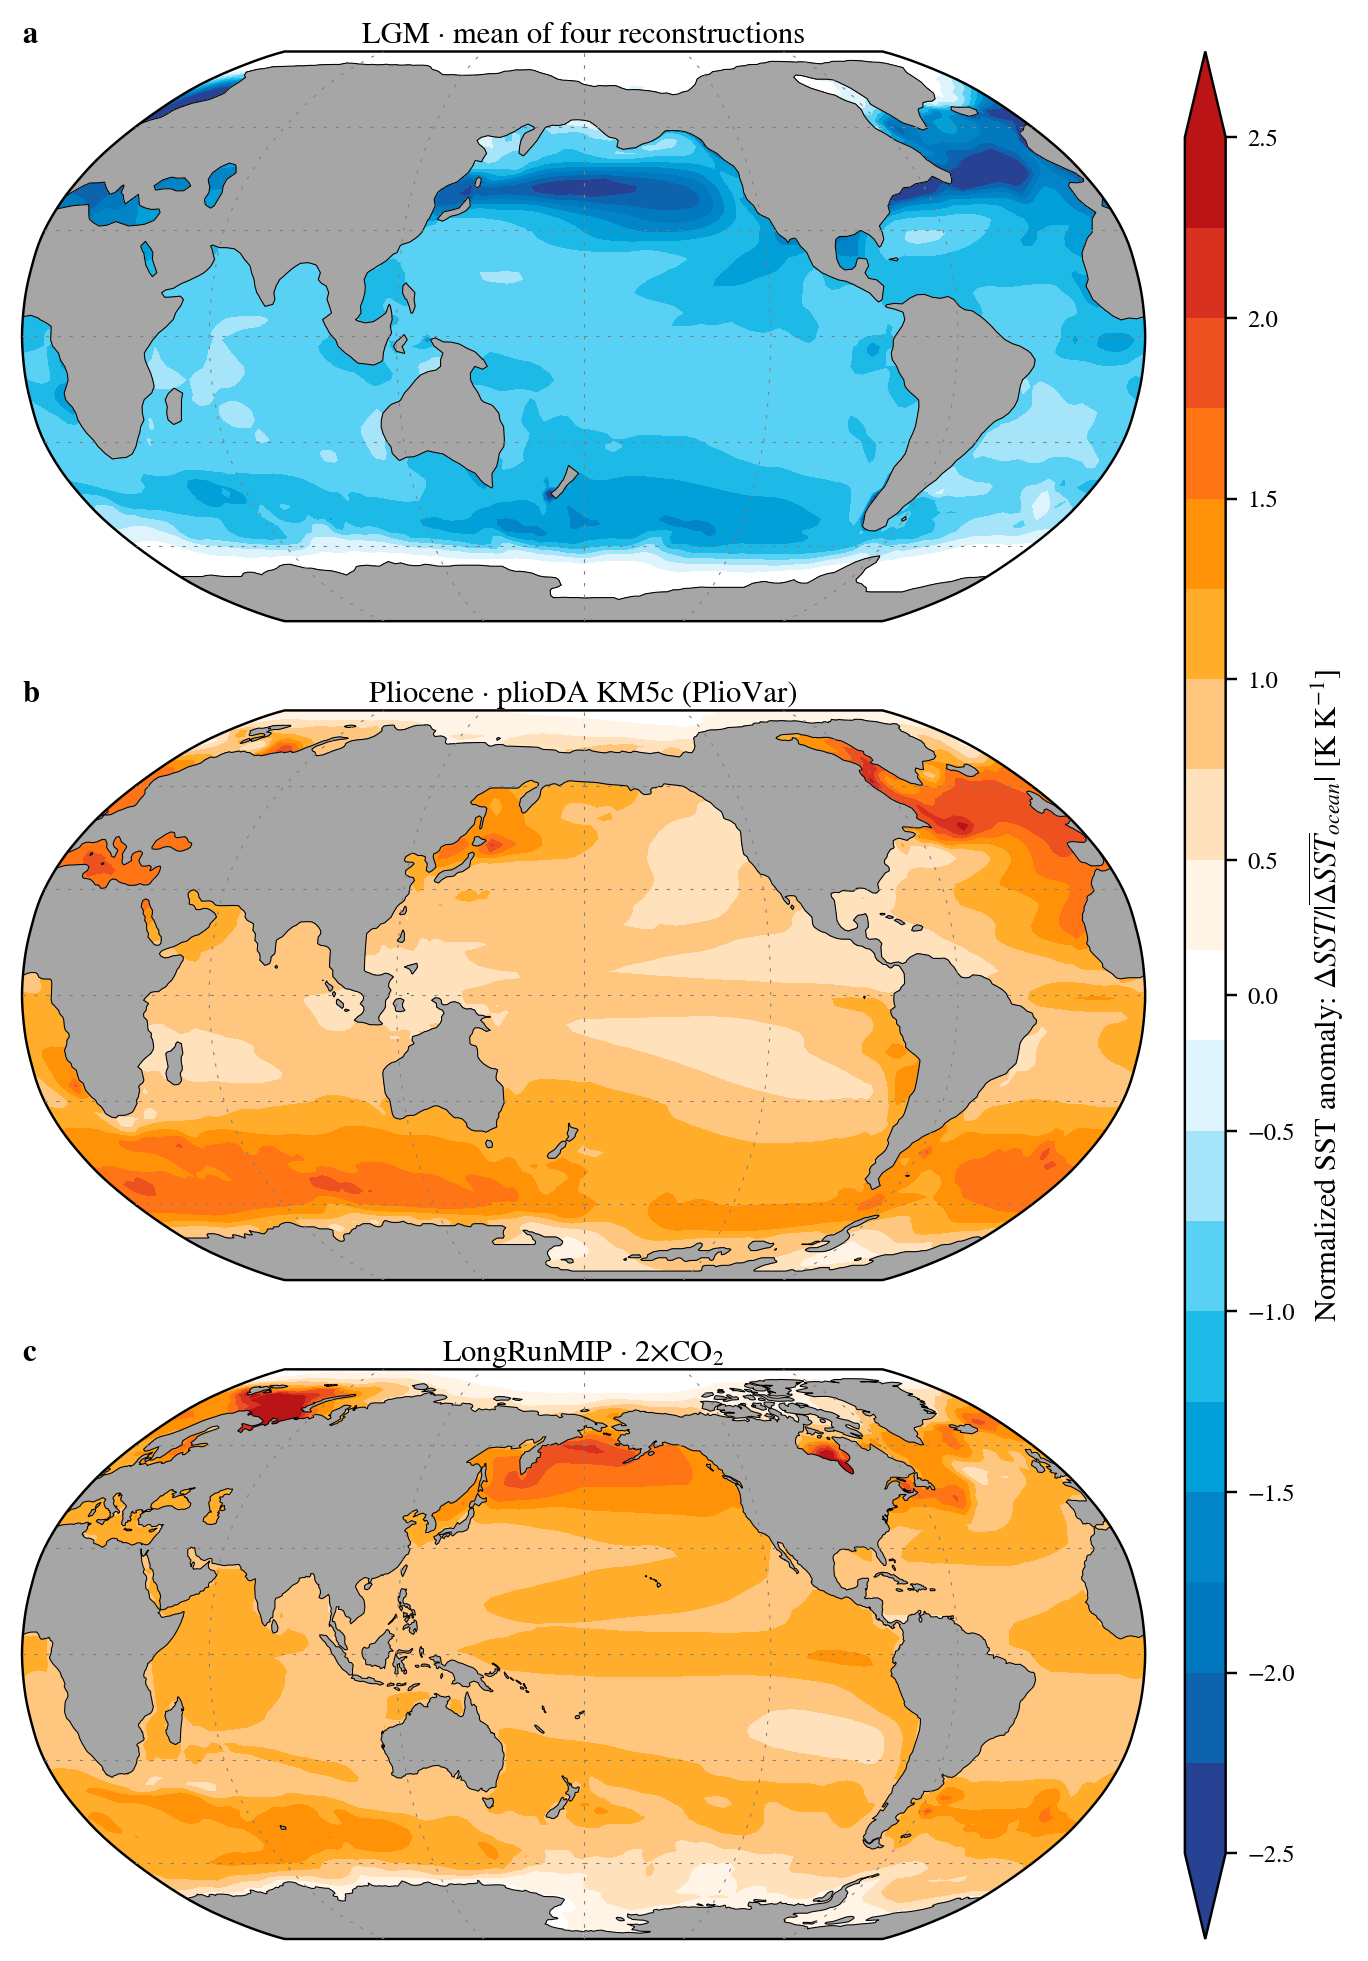

In [4]:
buor_colors = np.array([
    (39, 66, 147), (0, 115, 187), (1, 133, 199), (1, 174, 224),
    (88, 209, 244), (205, 238, 252), (255, 255, 255),
    (255, 238, 217), (255, 198, 127), (255, 161, 0),
    (255, 117, 21), (230, 63, 37), (187, 20, 22),
]) / 255.0
BuOr = LinearSegmentedColormap.from_list('BuOr', buor_colors)
assert NLEVELS % 2 == 0
levels = np.delete(np.linspace(-VABS, VABS, NLEVELS + 1), NLEVELS // 2)
cmap = BuOr.resampled(NLEVELS - 1)


def cyclic(field):
    field = field.transpose('lat', 'lon')
    values, longitude = add_cyclic_point(field.values, coord=field.lon.values, axis=-1)
    return longitude, field.lat.values, values


def fix_white_contours(contours):
    # Matplotlib >=3.8 makes the contour set itself a collection.
    if hasattr(contours, 'set_edgecolor'):
        contours.set_edgecolor('face')
        contours.set_linewidth(0.01)
    else:
        for collection in contours.collections:
            collection.set_edgecolor('face')
            collection.set_linewidth(0.01)


panels = [
    ('a', 'LGM · mean of four reconstructions', 'LGM', lgm_landfrac),
    ('b', 'Pliocene · plioDA KM5c (PlioVar)', 'Pliocene', plio_landfrac),
    ('c', r'LongRunMIP · 2×CO$_2$', 'LongRunMIP', None),
]
fig = plt.figure(figsize=(6.2, 8.8), dpi=220, layout='constrained')
grid = fig.add_gridspec(3, 2, width_ratios=(1, 0.035), hspace=0.045, wspace=0.025)
axes = [fig.add_subplot(grid[row, 0], projection=ccrs.Robinson(central_longitude=-180))
        for row in range(3)]
cax = fig.add_subplot(grid[:, 1])
for axis, (letter, title, key, landfrac) in zip(axes, panels):
    longitude, latitude, values = cyclic(normalized_sst.sel(pattern=key))
    contours = axis.contourf(
        longitude, latitude, values, levels=levels, cmap=cmap, extend='both',
        antialiased=False, transform=ccrs.PlateCarree(), zorder=1,
    )
    fix_white_contours(contours)
    if landfrac is None:
        axis.add_feature(cfeature.LAND.with_scale('110m'), facecolor='0.65',
                         edgecolor='none', zorder=2)
        axis.coastlines(resolution='110m', color='k', linewidth=0.35, zorder=3)
    else:
        coast_lon, coast_lat, coast_values = cyclic(landfrac)
        axis.contourf(
            coast_lon, coast_lat, coast_values,
            levels=[COAST_THRESHOLD, 1.01], colors=['0.65'],
            transform=ccrs.PlateCarree(), antialiased=False, zorder=2,
        )
        axis.contour(
            coast_lon, coast_lat, coast_values, levels=[COAST_THRESHOLD],
            colors='k', linewidths=0.35, transform=ccrs.PlateCarree(), zorder=3,
        )
    axis.set_global()
    axis.gridlines(color='grey', linewidth=0.35, linestyle=(0, (3, 8)),
                   draw_labels=False, alpha=1, zorder=3)
    axis.set_title(letter, loc='left', fontweight='bold', pad=3)
    axis.set_title(title, fontsize=10, pad=3)
    axis.set_facecolor('none')
colorbar = fig.colorbar(contours, cax=cax, orientation='vertical',
                        ticks=np.arange(-VABS, VABS + 0.01, 0.5))
colorbar.set_label(r'Normalized SST anomaly: $\Delta SST / |\overline{\Delta SST}_{ocean}|$ [K K$^{-1}$]')
fig.patch.set_alpha(0)
fig.patch.set_facecolor('none')
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for extension in ('png', 'pdf'):
        output = FIGURE_DIR / f'fig_paleo_patterns.{extension}'
        fig.savefig(output, bbox_inches='tight', dpi=700, transparent=True)
        print(f'Saved {output}')
plt.show()